<a href="https://colab.research.google.com/github/gloriaconcepto/ML-NLP-LEARNING/blob/main/Titanic_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [3]:
import os
import shutil

# Define the destination directory in your Google Drive
drive_dest_dir = '/content/drive/MyDrive/ML101/titanic_dataset'
# Create the destination directory in Drive if it doesn't exist
os.makedirs(drive_dest_dir, exist_ok=True)

In [4]:
!kaggle competitions download -c titanic -p $drive_dest_dir

  0% 0.00/34.1k [00:00<?, ?B/s]
100% 34.1k/34.1k [00:00<00:00, 3.96MB/s]


In [5]:
import zipfile

zip_path = os.path.join(drive_dest_dir, "titanic.zip")
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(drive_dest_dir)

In [ ]:
# import os
# import shutil

# # Define the destination directory in your Google Drive
# drive_dest_dir = '/content/drive/MyDrive/ML101/titanic_dataset'



# # List the files in the current directory (where the zip was extracted)
# extracted_files = os.listdir('.')

# # Copy the relevant files to Google Drive
# for file_name in extracted_files:
#     # You might want to refine this condition based on the actual file names
#     if file_name.endswith('.csv') or file_name.endswith('.txt'): # Example: copy CSV and text files
#         shutil.copy(file_name, drive_dest_dir)
#         print(f"Copied {file_name} to {drive_dest_dir}")

Actual Work start here

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning Function

In [4]:
def clean_titanic_data(df: pd.DataFrame, n_neighbors: int = 5) -> pd.DataFrame:
    df = df.copy()
    df = df.drop(["Name", "Ticket", "Cabin"], axis=1)

    # Encode categorical
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
    df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

    # Fill missing Embarked with mode
    if df["Embarked"].isna().sum() > 0:
        df.loc[:, "Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # KNN imputation for Age & Fare
    features = ["Age", "Pclass", "SibSp", "Parch", "Fare"]
    imputer = KNNImputer(n_neighbors=n_neighbors)
    df[features] = imputer.fit_transform(df[features])

    return df

# Step 2: Load & Prepare Dataset

In [5]:

df_train = pd.read_csv('/content/drive/MyDrive/ML101/titanic_dataset/train.csv')
df_train = clean_titanic_data(df_train)

X = df_train.drop("Survived", axis=1)
y = df_train["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# df_train.head()

# Step 3: Build Pipelines

In [6]:
pipelines = {
    "SGDClassifier": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(random_state=42, max_iter=1000, tol=1e-3))
    ]),
    "RandomForest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ])
}


# Step 4: Train & Evaluate Models

In [7]:
results = {}

for name, pipe in pipelines.items():
    print(f"\n=== {name} ===")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_prob": y_prob}


=== SGDClassifier ===
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       110
           1       0.66      0.68      0.67        69

    accuracy                           0.74       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.74      0.74       179

Confusion Matrix:
 [[86 24]
 [22 47]]

=== RandomForest ===
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       110
           1       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179

Confusion Matrix:
 [[95 15]
 [23 46]]

=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                     

# Step 5: ROC & Precision-Recall

In [8]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

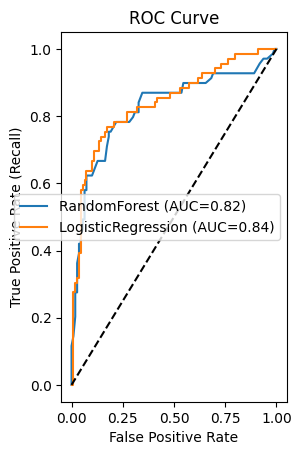

In [9]:
# ROC
plt.subplot(1, 2, 1)
for name, res in results.items():
    if res["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()

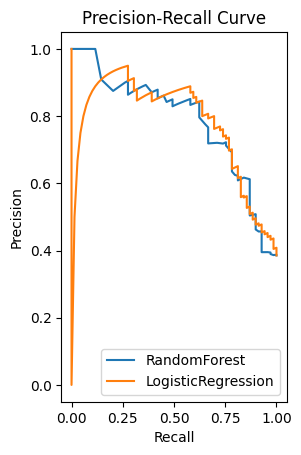

In [10]:
# Precision-Recall
plt.subplot(1, 2, 2)
for name, res in results.items():
    if res["y_prob"] is not None:
        precision, recall, _ = precision_recall_curve(y_test, res["y_prob"])
        plt.plot(recall, precision, label=f"{name}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.show()

# after analysis i have decided to use logisitic regression beacuse it have a high recall rate and a better AUC.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best recall:", grid.best_score_)


Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best recall: 0.7547474747474747


# Save the model

In [12]:
import joblib
from google.colab import drive

model_path = '/content/drive/MyDrive/ML101/titanic_dataset/titanic_survival_model.pkl'

# 3. Save the trained model (replace "best_model" with your chosen classifier)
joblib.dump(grid.best_estimator_, model_path)
print(f"Model saved at {model_path}")

# 4. To load the model later:
loaded_model = joblib.load(model_path)
print("Model loaded successfully!")

# Example prediction after loading:
sample_pred = loaded_model.predict(X_test[:5])
print("Sample predictions:", sample_pred)


Model saved at /content/drive/MyDrive/ML101/titanic_dataset/titanic_survival_model.pkl
Model loaded successfully!
Sample predictions: [0 0 0 0 1]


In [8]:
# Drop less useful columns
# df_train.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
# df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [16]:
#  check for any colums with a missing value
# df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [19]:
# import pandas as pd
# from sklearn.impute import KNNImputer

# def clean_titanic_data(df: pd.DataFrame, n_neighbors: int = 5) -> pd.DataFrame:
#     """
#     Clean Titanic dataset:
#     - Drop Name, Ticket, Cabin
#     - Encode Sex (male=0, female=1)
#     - Encode Embarked (S=0, C=1, Q=2)
#     - Handle missing values:
#         * Embarked -> fill with mode
#         * Age -> KNN Imputation

#     Parameters:
#         df (pd.DataFrame): Input Titanic dataframe
#         n_neighbors (int): Number of neighbors for KNN imputer

#     Returns:
#         pd.DataFrame: Cleaned dataframe
#     """
#     df = df.copy()  # avoid modifying original

#     # Drop unnecessary columns
#     df = df.drop(["Name", "Ticket", "Cabin"], axis=1)

#     # Encode categorical
#     df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
#     df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

#     # Handle missing Embarked with mode (no inplace to avoid warning)
#     if df["Embarked"].isna().sum() > 0:
#         df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

#     # KNN imputation for Age
#     age_features = ["Age", "Pclass", "SibSp", "Parch", "Fare"]
#     imputer = KNNImputer(n_neighbors=n_neighbors)
#     df[age_features] = imputer.fit_transform(df[age_features])

#     return df


In [20]:
# Clean train dataset
df_train_clean = clean_titanic_data(df_train)
